# What does a vision model see without labels?

This notebook reproduces the figures and numbers of the blog post [What Does a Vision Model See Without Labels?](https://karay.me/2026/10/01/unsupervised-feature-attribution.html). It follows the post section by section:

1. The images
2. Explaining a prediction by hiding parts of the image: RISE
3. No prediction to explain: RELAX
4. From an image to a grid of features
5. Explaining a prediction from the features: CAM and Grad-CAM
6. Label-free activation maps: ReLU, then average
7. A finer picture with AnyUp
8. A finer picture with LRP
9. The first figure: CNNs, local attention and three plain ViTs
10. A watermark in the web: maps as a debugging tool
11. When ReLU is not enough: plain vision transformers

Sections 2 to 5 show the methods the post starts from. RISE, CAM and Grad-CAM explain the prediction of a supervised classifier, and RELAX adapts RISE to encoders without one. From section 6 on, nothing needs labels, classifier heads or gradients of a prediction. Every map is computed from one image and one encoder. 

Everything the post explains is written out in this notebook. Loading the models, LRP and plotting live in the `xai_utils/` folder next to it. You do not need to read that code to follow along.

## 0. Setup

We use PyTorch, [timm](https://github.com/huggingface/pytorch-image-models) for the
pretrained encoders and [zennit](https://github.com/chr5tphr/zennit) for LRP. The
encoders are downloaded on first use.

In [1]:
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
import torchvision.transforms as T
from PIL import Image
from timm.data import ImageNetInfo

from xai_utils.lrp import explain
from xai_utils.models import IMAGENET_MEAN, IMAGENET_STD, load_model, MODELS
from xai_utils.plotting import show_images, show_rows

device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.set_grad_enabled(False)  # we mostly run the models forward; Grad-CAM and LRP switch gradients on by themselves
print('Running on', device)

Running on cuda


## 1. The images

Five images, each with more than one thing in it. Every encoder sees the same 224×224 crop: the short side is resized to 224 pixels and the centre is cut out.

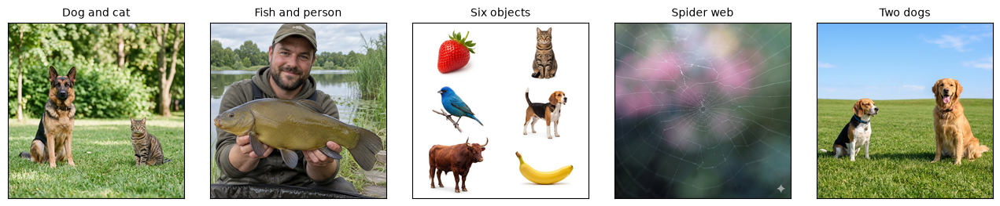

In [2]:
crop = T.Compose(
    [
      T.Resize(224, interpolation=T.InterpolationMode.LANCZOS),
      T.CenterCrop(224)
    ]
)
images = {
    path.stem: crop(Image.open(path).convert("RGB"))
    for path in sorted(Path("images").glob("*.*"))
}

show_images(
    list(images.values()), [name.replace("_", " ").capitalize() for name in images]
)

In [3]:
print("Available models:\n" + "\n".join(MODELS))

Available models:
resnet50
convnext
swin
maxvit
clip_convnext
dino_resnet50
dinov3_convnext
vit
clip_vit
dinov2
dino_vit
dinov3_vit
mae
vit_augreg
deit
deit3
dinov2_reg


## 2. Explaining a prediction by hiding parts of the image: RISE

Before looking inside the encoders, let us explain a prediction the classic way. A supervised ResNet-50 classifies the dog-and-cat image, and [RISE](https://arxiv.org/abs/1806.07421) asks which parts of the image the score of one class depends on. It hides random parts of the image, runs the classifier on every masked copy and records the probability of the class. Masks that keep the important parts get high scores.

`load_model` wraps each model so that calling it returns the feature grid, and `transform` turns an image into the normalized tensor the model expects. The full classifier, with its head, is still there as `.model`. First, the classifier's own answer.

In [4]:
classes = ImageNetInfo()   # the names of the 1000 ImageNet classes
DOG, CAT = 235, 281        # 'German shepherd' and 'tabby cat'

dog_and_cat = images['dog_and_cat']
classifier = load_model('resnet50')

# (1, 3, 224, 224): normalized, with a batch dimension
x = classifier.transform(dog_and_cat)[None].to(device)

probabilities = classifier.model(x).softmax(-1)[0]
top = probabilities.topk(3)

for p, c in zip(top.values, top.indices):
    print(f'{p:.3f}  {classes.index_to_description(int(c))}')

print(f'{probabilities[CAT]:.3f}  {classes.index_to_description(CAT)}')

0.989  German shepherd, German shepherd dog, German police dog, alsatian
0.009  malinois
0.000  Norwegian elkhound, elkhound
0.000  tabby, tabby cat


The classifier is sure it sees a German shepherd and gives the cat almost no chance. RISE can still explain either class, because it only needs a score to watch.

Now the masks. Each one starts as a random 7×7 pattern in which every cell is kept with probability `P = 0.5`. The pattern is blown up smoothly to the image size and shifted by a random amount, so the soft edges fall in different places for every mask. Hidden pixels are set to zero after normalization, which is the average colour the model was normalized with, a greyish brown.

We draw all 3000 masks that RISE will use at once. Here are the first six, the masked images, and the two probabilities for each.

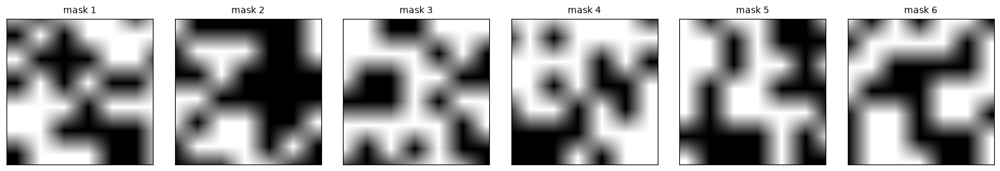

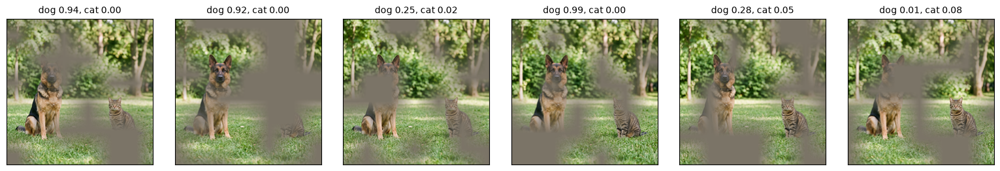

In [5]:
# RISE uses a few thousand; fewer masks are faster but noisier
N_MASKS = 3000
# each mask starts as a 7x7 pattern in which every cell is kept with probability 0.5
GRID, P = 7, 0.5
CELL = 224 // GRID   # 32 px
generator = torch.Generator().manual_seed(0)

# a coarse pattern for every mask, 1 = keep the cell, 0 = hide it
masks = (torch.rand(N_MASKS, 1, GRID, GRID, generator=generator) < P).float()
# blown up smoothly to one cell more than the image size
masks = F.interpolate(masks, size=(GRID + 1) * CELL, mode='bilinear', align_corners=False)[:, 0]
# a randomly shifted 224x224 window of each, so the soft edges fall in different places
shifts = torch.randint(0, CELL, (N_MASKS, 2), generator=generator).tolist()
masks = torch.stack([mask[dy:dy + 224, dx:dx + 224] for mask, (dy, dx) in zip(masks, shifts)])   # (3000, 224, 224)

first = masks[:6]
scores = classifier.model(x * first[:, None].to(device)).softmax(-1)[:, [DOG, CAT]].cpu()

pixels = np.asarray(dog_and_cat) / 255
hidden = np.array(classifier.mean)   # what a zero looks like after normalization
masked = [pixels * mask[..., None] + (1 - mask[..., None]) * hidden for mask in first.numpy()]
show_images([mask[..., None].repeat(3, axis=-1) for mask in first.numpy()], [f'mask {i + 1}' for i in range(6)])
show_images(masked, [f'dog {d:.2f}, cat {c:.2f}' for d, c in scores.tolist()])

To turn the scores into a map, every mask is multiplied by its score and all masks are added up. A pixel that was visible whenever the score was high collects a lot. A pixel that was visible just as often when the score was low collects less. Dividing by the number of masks and by `P` makes each pixel's value roughly the average score of the masked images in which that pixel was visible.

The next cell does exactly this. It runs the classifier on the masked copies 100 at a time, keeps both probabilities, and weights every mask by them, so the dog map and the cat map come from the same masked images.

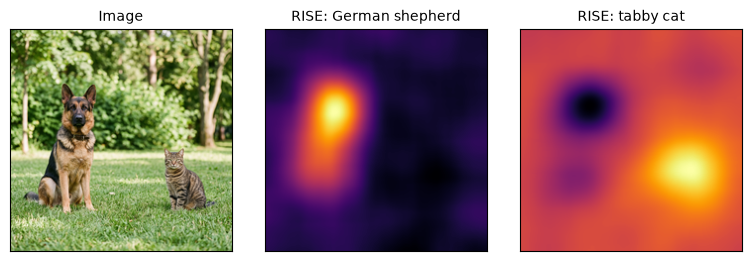

In [6]:
scores = []
for batch in masks.split(100):   # 100 masked copies of the image at a time
    x_masked = x * batch[:, None].to(device)
    logits = classifier.model(x_masked)
    scores.append(logits.softmax(-1)[:, [DOG, CAT]].cpu())
scores = torch.cat(scores)       # (3000, 2): one probability per mask and class

# every mask weighted by its score, all added up, and divided by the number of masks and P
rise = (scores.T @ masks.flatten(1) / (N_MASKS * P)).reshape(2, 224, 224)
show_images([dog_and_cat, rise[0], rise[1]], ['Image', 'RISE: German shepherd', 'RISE: tabby cat'])

The same classifier and the same image give two different maps, one for each class we ask about. Without a class score, RISE has nothing to watch.

It is also expensive. One map took 3000 forward passes, and the maps from only the first 100 or 500 masks are still noisy:

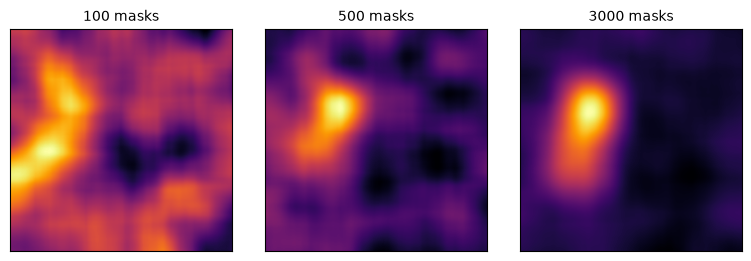

In [7]:
maps = [(scores[:n, 0] @ masks[:n].flatten(1) / (n * P)).reshape(224, 224) for n in (100, 500, N_MASKS)]
show_images(maps, ['100 masks', '500 masks', f'{N_MASKS} masks'])

## 3. No prediction to explain: RELAX

A self-supervised encoder has no class probabilities, only an embedding, a vector of numbers without names. [RELAX](https://arxiv.org/abs/2112.10161) keeps RISE's masks and replaces the class score with a comparison. The embedding of the full image is the reference. Each masked copy is scored by how similar its embedding still is to the reference, measured by the cosine similarity. If hiding a region changes the embedding a lot, that region mattered to the encoder.

We use DINOv1 ResNet-50, which was trained without labels. Its embedding is the average of the final feature grid over all positions, the vector a ResNet would pass on to a classifier head. Here are the same six masks as above, now scored by similarity.

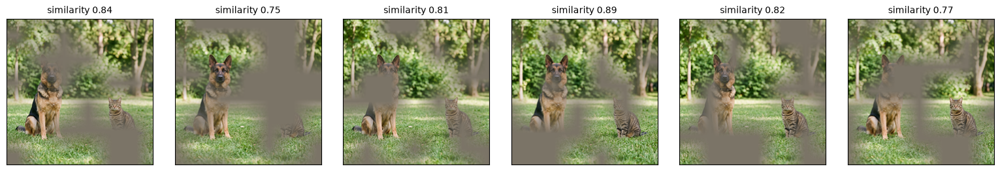

In [8]:
dino = load_model('dino_resnet50')
x = dino.transform(dog_and_cat)[None].to(device)
reference = dino(x).mean(dim=(2, 3))                          # the embedding of the full image: (1, 2048)
embeddings = dino(x * first[:, None].to(device)).mean(dim=(2, 3))   # one embedding per masked copy: (6, 2048)
similarities = F.cosine_similarity(embeddings, reference).cpu()
show_images(masked, [f'similarity {s:.2f}' for s in similarities.tolist()])

The rest is RISE's loop with the new score, with one difference. RISE divides by the number of masks in which a pixel is visible on average, `N_MASKS * P`. RELAX divides by how often each pixel was actually visible, so every pixel gets exactly the average similarity of the masked copies in which it was visible. The similarities vary far less than class probabilities do, and with RISE's division the small chance differences in how often pixels were visible would show up as blotches in the map.

We also run RELAX on the supervised ResNet-50, ignoring its head. RELAX only needs an embedding, so it works for any encoder.

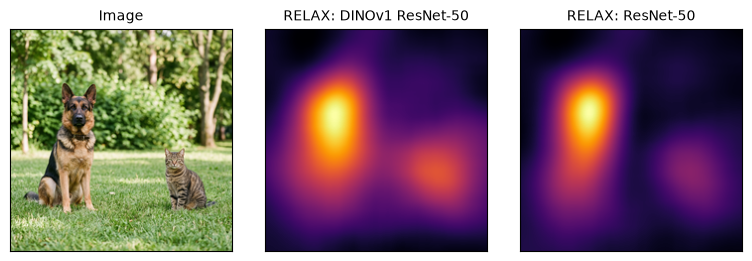

In [9]:
relax = {}
for title, model in [('DINOv1 ResNet-50', dino), ('ResNet-50', classifier)]:
    x = model.transform(dog_and_cat)[None].to(device)
    # the feature grid before the pooling layer: (1, 2048, 7, 7) for both models
    reference = model(x)
    # averaged over all positions, as global average pooling would, this is the embedding of the full image
    reference = reference.mean(dim=(2, 3))
    similarities = []
    for batch in masks.split(100):
        # compute embeddings from masked images
        embeddings = model(x * batch[:, None].to(device)).mean(dim=(2, 3))
        # measure similarity of each masked embedding to the reference embedding
        similarities.append(F.cosine_similarity(embeddings, reference).cpu())
    similarities = torch.cat(similarities)   # (3000,)
    # the average similarity of the masked copies in which each pixel was visible
    relax[title] = (similarities @ masks.flatten(1)).reshape(224, 224) / masks.sum(0)

show_images([dog_and_cat] + list(relax.values()), ['Image'] + [f'RELAX: {title}' for title in relax])

Both maps are brightest on the dog. The self-supervised DINOv1 ResNet-50 also picks up the cat, while the supervised ResNet-50 hardly does.

RELAX needs no label, which is exactly what a self-supervised encoder requires. The paper also uses the spread of the scores to estimate how uncertain each pixel's value is, which we leave out here. The maps are smooth but coarse, because every mask hides whole cells of 32×32 pixels with soft edges. RELAX also keeps RISE's cost of thousands of forward passes per map. And masking is not innocent. Grey patches look nothing like natural images, so part of the change in the embedding may come from the patches themselves.

The rest of this notebook takes a different route. It looks at the features an encoder computes for the unmodified image, in a single forward pass.

## 4. From an image to a grid of features

An encoder turns the image into a grid of feature vectors. A CNN such as ResNet-50 shrinks the image step by step, so its last layer holds a 7×7 grid, and every cell of the grid is a vector of 2048 numbers (channels). Each channel on its own is an *activation map*: a 7×7 picture of where that feature responds.

feature grid: (2048, 7, 7)


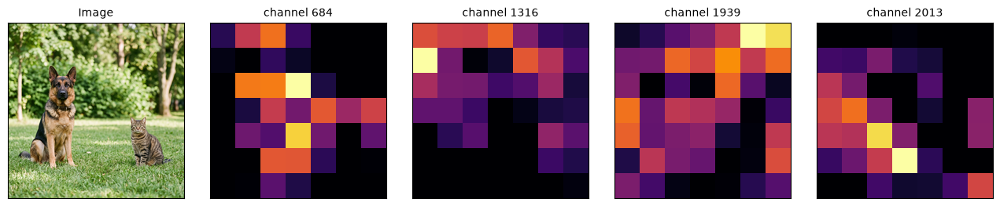

In [10]:
x = classifier.transform(dog_and_cat)[None].to(device)
features = classifier(x)[0]   # (channels, height, width): (2048, 7, 7)
print('feature grid:', tuple(features.shape))

# four individual channels, picked at random
channels = torch.randperm(features.shape[0], generator=torch.Generator().manual_seed(0))[:4]
show_images([dog_and_cat] + [features[c] for c in channels],
            ['Image'] + [f'channel {int(c)}' for c in channels])

Individual channels respond to different parts of the image, and on their own they do not mean much. The question of the post is what happens when we combine all of them, without asking the model for a prediction. First, though, let us see how a classifier combines them.

## 5. Explaining a prediction from the features: CAM and Grad-CAM

A supervised classifier combines these channels in a very particular way. ResNet-50 averages its final 7×7 grid over all positions (global average pooling) and passes the resulting 2048 numbers to a single linear layer, with one weight per channel and class. Averaging and a linear layer can be swapped. The class score is therefore the average, over the positions, of a weighted sum of the channels. That weighted sum before the averaging is the class activation map ([CAM](https://arxiv.org/abs/1512.04150)). It says how much each position adds to the score of the class.

German shepherd score 17.7690, average of its CAM + bias 17.7690


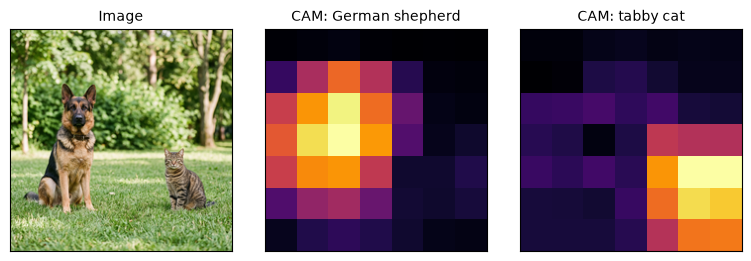

In [11]:
# one weight per class and channel (1000 x 2048), plus a bias per class
head = classifier.model.fc
# every class's weights times the features of every cell
cams = (head.weight @ features.flatten(1)).reshape(-1, 7, 7)

# the class score is indeed the average of its CAM (plus the bias)
print(f'German shepherd score {classifier.model(x)[0, DOG]:.4f}, '
      f'average of its CAM + bias {cams[DOG].mean() + head.bias[DOG]:.4f}')
show_images([dog_and_cat, cams[DOG], cams[CAT]], ['Image', 'CAM: German shepherd', 'CAM: tabby cat'])

CAM needs exactly this design, global average pooling followed by one linear layer. Many classifiers add more after the pooling. ConvNeXt normalizes the pooled vector, and MaxViT adds a hidden layer with a tanh before the final one. [Grad-CAM](https://arxiv.org/abs/1610.02391) works for all of them. It takes the gradient of the class score with respect to the feature grid and averages it over the positions, which gives one weight per channel. These weights are used like CAM's, and only the positive part of the result is kept.

For ResNet-50, Grad-CAM reproduces CAM. The gradient of an average over 49 positions is just the classifier weight divided by 49.

Grad-CAM equals ReLU(CAM) / 49 for ResNet-50: True


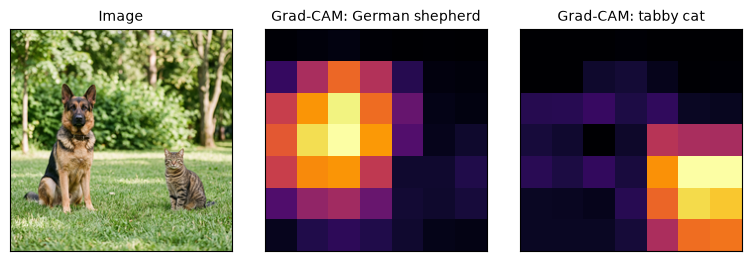

In [12]:
grad_cams = {}
# gradients are switched off in this notebook, except here and in LRP
with torch.enable_grad():
    # the features, with gradients tracked
    tracked = classifier.model.forward_features(x).detach().requires_grad_()
    logits = classifier.model.forward_head(tracked)[0]
    for cls in (DOG, CAT):
        gradient, = torch.autograd.grad(logits[cls], tracked, retain_graph=True)
        channel_weights = gradient[0].mean(dim=(1, 2))   # one weight per channel
        grad_cams[cls] = F.relu((channel_weights[:, None, None] * tracked[0]).sum(0))

print('Grad-CAM equals ReLU(CAM) / 49 for ResNet-50:',
      torch.allclose(grad_cams[DOG], F.relu(cams[DOG]) / 49, atol=1e-5))
show_images([dog_and_cat, grad_cams[DOG], grad_cams[CAT]], ['Image', 'Grad-CAM: German shepherd', 'Grad-CAM: tabby cat'])

### What about vision transformers?

Nothing in CAM or Grad-CAM is specific to convolutions. Both need a grid of feature vectors and a classifier on top. Swin, one of the transformers with local attention in the post, is built like ResNet-50 at the end. It layer-normalizes each of its final 7×7 tokens, averages them and passes the result to a single linear layer. CAM therefore applies exactly.

German shepherd score 8.6210, average of its CAM + bias 8.6210


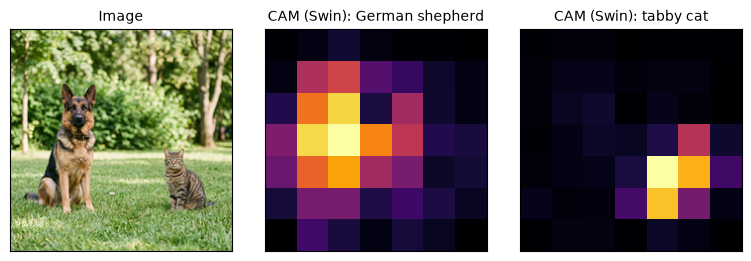

In [13]:
swin = load_model('swin')
x = swin.transform(dog_and_cat)[None].to(device)
features = swin(x)[0]   # (1024, 7, 7), already layer-normalized per token
head = swin.model.head.fc
cams = (head.weight @ features.flatten(1)).reshape(-1, 7, 7)

print(f'German shepherd score {swin.model(x)[0, DOG]:.4f}, '
      f'average of its CAM + bias {cams[DOG].mean() + head.bias[DOG]:.4f}')
show_images([dog_and_cat, cams[DOG], cams[CAT]], ['Image', 'CAM (Swin): German shepherd', 'CAM (Swin): tabby cat'])

The plain ViT-B/16 from the post is different. It does not average its patch tokens. It classifies from an extra class token, which gathers information from the patch tokens through attention. There is no average to decompose, so CAM does not apply.

Grad-CAM does apply, but not at the last layer. The patch tokens that come out of the final block are never read by anything, because only the class token goes on to the classifier. Their gradient is exactly zero.

In [14]:
vit = load_model('vit')
x = vit.transform(dog_and_cat)[None].to(device)
probabilities = vit.model(x)[0].softmax(-1)
top = probabilities.topk(3)
for p, c in zip(top.values, top.indices):
    print(f'{p:.3f}  {classes.index_to_description(int(c))}')

with torch.enable_grad():
    # class token + 196 patch tokens
    tokens = vit.model.forward_features(x).detach().requires_grad_()
    # reads only the class token
    score = vit.model.forward_head(tokens)[0, DOG]
    gradient, = torch.autograd.grad(score, tokens)
print('largest gradient on the final patch tokens:', float(gradient[0, 1:].abs().max()))

0.436  German shepherd, German shepherd dog, German police dog, alsatian
0.246  tiger cat
0.163  tabby, tabby cat
largest gradient on the final patch tokens: 0.0


The ViT sees the cat as well, as a tiger cat or a tabby. Inside the last block, the
gradient is no longer zero. The block still lets the class token read from the patch
tokens, so the tokens it reads from influence the score. We take them right after the
block's first layer normalization, where they enter the attention. This is also the
layer that common Grad-CAM libraries use for ViTs. Grad-CAM then works as on a CNN's
grid. The tokens only form a list, so we fold the result back into the 14×14 patch
grid at the end.

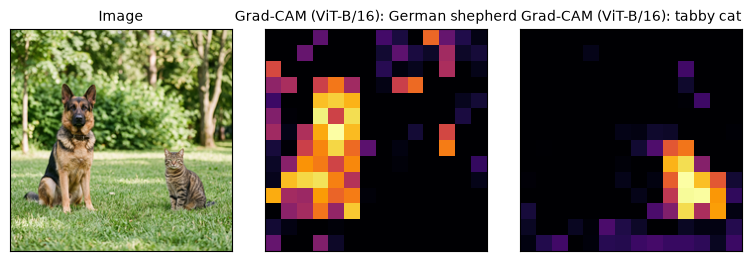

In [15]:
def grad_cam_vit(model, x, cls, layer):
    # Grad-CAM on the tokens that `layer` outputs
    captured = {}
    hook = layer.register_forward_hook(
        lambda module, inputs, output: captured.update(tokens=output)
    )
    with torch.enable_grad():
        score = model(x)[0, cls]
        (gradient,) = torch.autograd.grad(score, captured["tokens"])
    hook.remove()
    k = model.num_prefix_tokens  # skip the class token
    channel_weights = gradient[0, k:].mean(0)  # one weight per channel, as before
    cam = F.relu(captured["tokens"][0, k:] @ channel_weights)
    side = int(cam.numel() ** 0.5)
    return cam.reshape(side, side)


inside_last_block = vit.model.blocks[-1].norm1
show_images(
    [
        dog_and_cat,
        grad_cam_vit(vit.model, x, DOG, inside_last_block),
        grad_cam_vit(vit.model, x, CAT, inside_last_block),
    ],
    [
        "Image",
        "Grad-CAM (ViT-B/16): German shepherd",
        "Grad-CAM (ViT-B/16): tabby cat"
    ],
)

The layer normalization matters here. Without it, a few tokens in the background hold one enormous value each. They are the outlier tokens we will meet again in section 11. Grad-CAM multiplies the token values by the channel weights, so these tokens take over the map. The layer normalization divides every token by the spread of its values and flattens them.

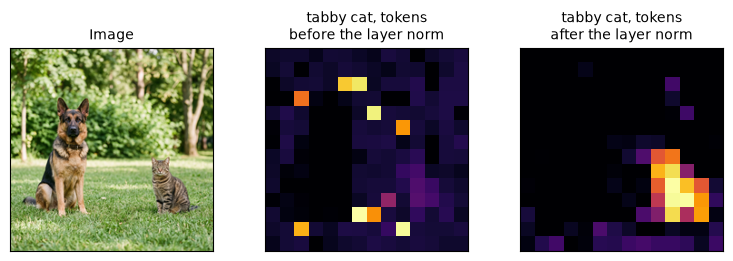

In [16]:
entering_last_block = vit.model.blocks[-2]  # its output is what enters the last block
show_images(
    [
        dog_and_cat,
        grad_cam_vit(vit.model, x, CAT, entering_last_block),
        grad_cam_vit(vit.model, x, CAT, inside_last_block),
    ],
    [
        "Image",
        "tabby cat, tokens\nbefore the layer norm",
        "tabby cat, tokens\nafter the layer norm",
    ],
)

**A note on naming.** "Grad-CAM for vision transformers" means different things in different papers. Here, it is applied to the token features, with the token grid treated like a CNN's feature map. The [pytorch-grad-cam](https://jacobgil.github.io/pytorch-gradcam-book/vision_transformers.html) library does the same. Others apply it to the attention maps of the last block, with the attention heads in place of channels. This is the Grad-CAM baseline of [Chefer et al. (2021)](https://arxiv.org/abs/2012.09838), against which many ViT explanation methods are compared. Methods built for transformers go further, such as [Attention Guided CAM](https://arxiv.org/abs/2402.04563), which combines attention maps with their gradients. The layer and the tensor change the map considerably, and a recent audit found that papers rarely say which ones they use ([Wall et al., 2026](https://arxiv.org/abs/2608.05258)). The original CAM is rarely used for transformers at all, since most ViTs classify from a class token and have no average to decompose. Swin, above, is an exception.

Both methods take their channel weights from the classifier, and each class gets its own weights and its own map. A self-supervised encoder has no classifier, so there are no class weights to take and no score to differentiate.

In [17]:
del classifier, dino, swin, vit   # free the memory before the next sections load more models

## 6. Label-free activation maps: ReLU, then average

CAM and Grad-CAM weight every channel by how much it matters for one class. Without a class, we give every channel the same weight: we keep the positive part of each value (ReLU) and average over the channels. A location becomes bright when many channels respond there, or when a few respond strongly.

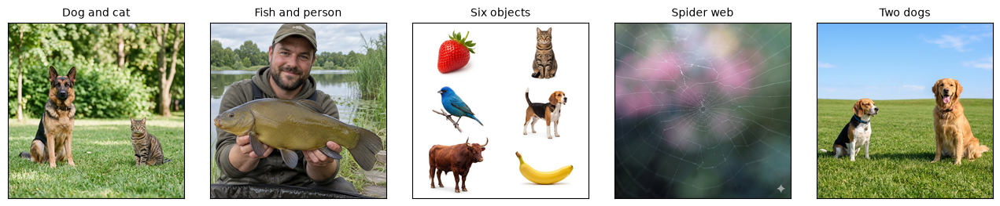

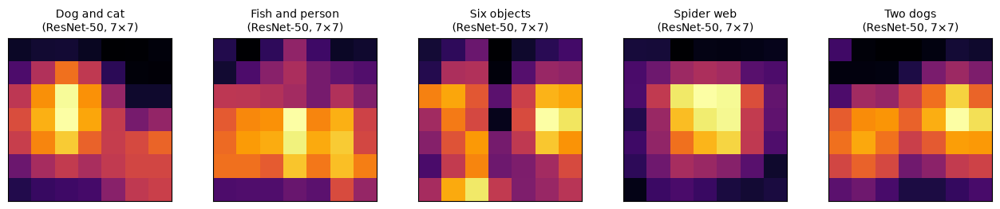

In [18]:
model = load_model("resnet50")

maps = {}
for name, image in images.items():
    x = model.transform(image)[None].to(device)
    features = model(x)[0]  # (2048, 7, 7)
    maps[name] = F.relu(features).mean(0)  # ReLU, then average over the channels

show_images(images.values(), [name.replace("_", " ").capitalize() for name in maps])
show_images(
    list(maps.values()),
    [f"{name.replace('_', ' ').capitalize()}\n(ResNet-50, 7×7)" for name in maps],
)

Even though ResNet-50 was trained to name a single class per image, the map covers more than one object. Both dogs light up, so do the fish and the person, and so do all six objects. In the image of the dog and the cat, the cat stands out less than the dog. The catch is the resolution. Each block is one of the 7×7 feature cells, 32×32 pixels of the input.

## 7. A finer picture with AnyUp

[AnyUp](https://github.com/wimmerth/anyup) is a pretrained feature upsampler. It takes the coarse feature grid together with the image and predicts the features at full resolution. Every upsampled feature vector is a weighted average of nearby coarse vectors, with the weights chosen by looking at the image. AnyUp can therefore move the edges of a response to where the image has edges, but it cannot create a response that the coarse grid does not have.

We upsample all channels and then reduce them exactly as before.

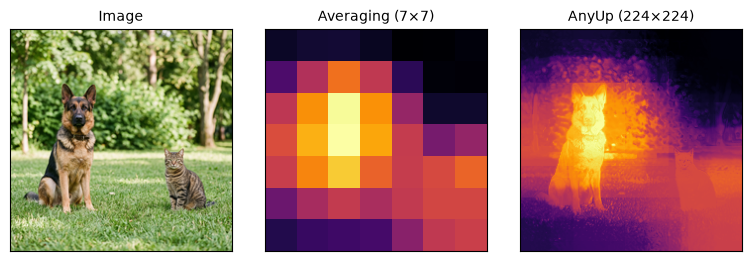

In [19]:
upsampler = (
    torch.hub.load("wimmerth/anyup", "anyup", trust_repo=True, verbose=False)
    .to(device)
    .eval()
)
# AnyUp expects the image normalized with ImageNet statistics, whatever the model
imagenet_transform = T.Compose([T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)])
guide = imagenet_transform(dog_and_cat)[None].to(device)

x = model.transform(dog_and_cat)[None].to(device)
features = model(x)[0]
upsampled = upsampler(guide, features[None])[0]  # (2048, 224, 224)
show_images(
    [dog_and_cat, F.relu(features).mean(0), F.relu(upsampled).mean(0)],
    ["Image", "Averaging (7×7)", "AnyUp (224×224)"],
)

## 8. A finer picture with LRP

Layer-wise relevance propagation (LRP) goes the other way: instead of upsampling the features, it traces them back through the network to the pixels. Classic LRP starts from a class score. Here there is no score, so we start from the features themselves: an amount of 1 is put on the feature values, and LRP passes it back layer by layer. How the amount is split at each layer is decided by propagation rules; the ones used here are in `xai_utils/lrp.py`.

The starting amount is spread over the feature values in proportion to how active each one is (its positive part). Strongly responding features start with more relevance, and inactive ones start with none. This is the same quantity the averaged map shows, so LRP traces that map back to the pixels.

The result has one value per pixel and colour channel. We show its positive part, averaged over the colour channels.

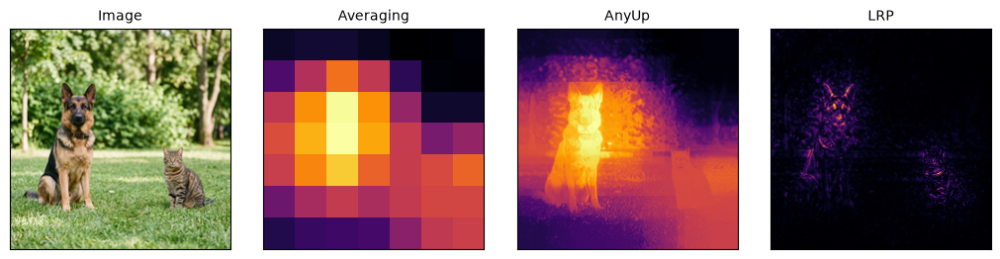

In [20]:
relevance = explain(model, x)
show_images(
    [
        dog_and_cat,
        F.relu(features).mean(0),
        F.relu(upsampled).mean(0),
        relevance.clamp(min=0).mean(0),
    ],
    ["Image", "Averaging", "AnyUp", "LRP"],
)

AnyUp fills each object evenly and gives it a sharp border. LRP concentrates on contours, faces and other structure inside the objects, and little of it reaches the background.

## 9. The first figure: CNNs, local attention and three plain ViTs

Now the same three maps for all encoders of the post's first figure. Change `IMAGE` to look at another picture. Every map is stretched between its own minimum and maximum, so brightness compares positions within one panel, not across panels.

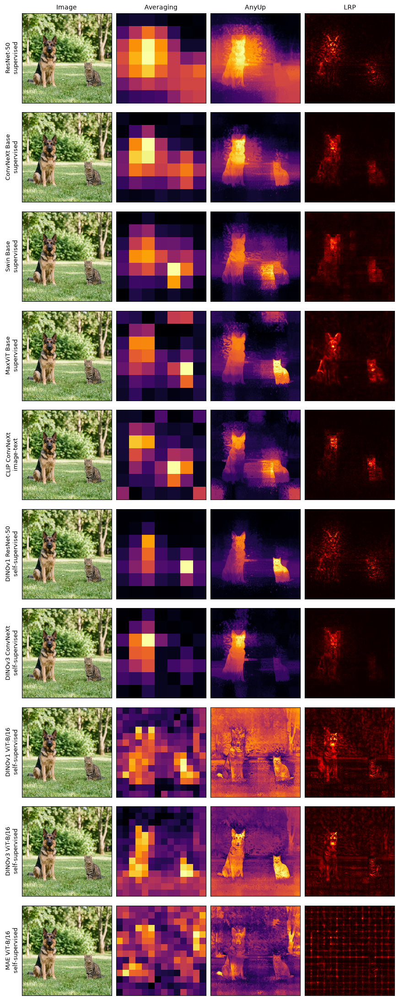

In [21]:
IMAGE = "dog_and_cat"  # one of: dog_and_cat, fish_and_person, six_objects, spider_web, two_dogs
FIRST_GALLERY = [
    "resnet50",
    "convnext",
    "swin",
    "maxvit",
    "clip_convnext",
    "dino_resnet50",
    "dinov3_convnext",
    "dino_vit",
    "dinov3_vit",
    "mae",
]

image = images[IMAGE]
guide = imagenet_transform(image)[None].to(device)  # the same for every model
rows = []
for key in FIRST_GALLERY:
    model = load_model(key)
    x = model.transform(image)[None].to(device)
    features = model(x)[0]
    upsampled = upsampler(guide, features[None])[0]
    relevance = explain(model, x)
    maps = [
        F.relu(features).mean(0),
        F.relu(upsampled).mean(0),
        relevance.clamp(min=0).mean(0),
    ]
    rows.append((f"{model.info.label}\n{model.info.training}", maps))

show_rows(
    image, rows, ["Averaging", "AnyUp", "LRP"], cmaps=["inferno", "inferno", "hot"]
)

## 10. A watermark in the web: maps as a debugging tool

The spider web image has a small sparkle in its bottom-right corner, the watermark of the image generator that created it. Nobody asked the models about it and no label points to it, yet the maps show that some encoders respond to it. This is the kind of finding that makes label-free maps useful for debugging. In the 224×224 crop it sits inside the feature cell in row 6, column 6 of the 7×7 grid, and covers less than one percent of the image.

For two encoders, we compute four maps. The averaged map and the LRP map as before, then two ways of setting the watermark aside:

- scale the LRP map by its largest value **outside** the watermark, so that the watermark no longer sets the colour scale, and
- leave the watermark's cell out of LRP's starting amount (`exclude=[(6, 6)]`).

We also measure which share of the LRP relevance lands on the watermark.

MaxViT Base: watermark cell is number 22 of 49 in the averaged map; LRP puts 8.0% of the relevance on the watermark (peak 3.7x the rest), 7.5% when its cell is left out


CLIP ConvNeXt: watermark cell is number 1 of 49 in the averaged map; LRP puts 5.1% of the relevance on the watermark (peak 2.0x the rest), 2.2% when its cell is left out


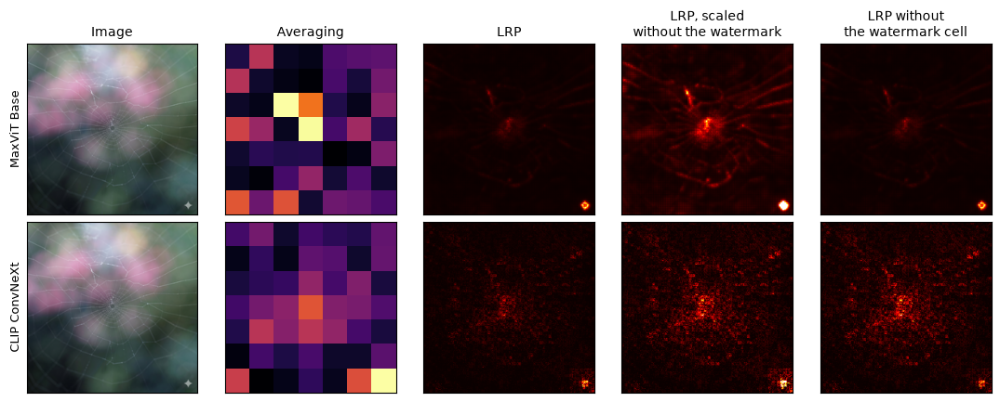

In [22]:
WATERMARK = (
    slice(203, 220),
    slice(203, 220),
)  # a small box around the watermark in the crop
WATERMARK_CELL = (6, 6)  # the 7x7 feature cell that contains it

web = images["spider_web"]
rows = []
for key in ["maxvit", "clip_convnext"]:
    model = load_model(key)
    x = model.transform(web)[None].to(device)
    averaged = F.relu(model(x)[0]).mean(0)
    relevance = explain(model, x).clamp(min=0).mean(0)
    without_cell = explain(model, x, exclude=[WATERMARK_CELL]).clamp(min=0).mean(0)
    outside = relevance.clone()
    outside[WATERMARK] = 0
    rescaled = (relevance / outside.max()).clamp(max=1)

    rank = int((averaged > averaged[WATERMARK_CELL]).sum()) + 1
    share = relevance[WATERMARK].sum() / relevance.sum()
    share_without_cell = without_cell[WATERMARK].sum() / without_cell.sum()
    print(
        f"{model.info.label}: watermark cell is number {rank} of 49 in the averaged map; "
        f"LRP puts {share:.1%} of the relevance on the watermark "
        f"(peak {relevance[WATERMARK].max() / outside.max():.1f}x the rest), "
        f"{share_without_cell:.1%} when its cell is left out"
    )
    rows.append((model.info.label, [averaged, relevance, rescaled, without_cell]))

show_rows(
    web,
    rows,
    [
        "Averaging",
        "LRP",
        "LRP, scaled\nwithout the watermark",
        "LRP without\nthe watermark cell",
    ],
    cmaps=["inferno", "hot", "hot", "hot"],
)

For CLIP ConvNeXt, the watermark's cell is the brightest cell of the averaged map, and leaving it out of the starting amount cuts the share on the watermark by more than half. MaxViT hardly reacts to the watermark in the averaged map, yet its LRP map puts a large share of the relevance there. Leaving out the cell barely helps, because relevance reaches the watermark from cells all over the image. Only the rescaled map shows that the threads of the web were there all along.

The example also shows where the maps stop. They say where the representation responds, not what the response is about. We recognized the watermark by looking at the image.

## 11. When ReLU is not enough: plain vision transformers

A plain vision transformer (ViT) cuts the image into 16×16 patches and keeps one
feature vector (token) per patch through the whole network. Folding the tokens back
into their patch grid gives a 14×14 grid, and we can reduce it exactly like a CNN's.

Three plain ViTs are already in the first figure, DINOv1, DINOv3 and MAE, and their
maps look much like those of the CNNs. For three others, the supervised ViT-B/16,
CLIP ViT-B/16 and DINOv2, the map is bright almost everywhere apart from a few very
dark tokens. First a fact check. Are their feature values mostly negative, so that
the ReLU throws most of them away?

In [23]:
PLAIN_VITS = ['dino_vit', 'dinov3_vit', 'mae', 'vit', 'clip_vit', 'dinov2']

for key in ['resnet50', 'convnext'] + PLAIN_VITS:
    model = load_model(key)
    shares = []
    for image in images.values():
        features = model(model.transform(image)[None].to(device))[0]
        shares.append(float((features > 0).float().mean()))   # the fraction of positive values
    print(f'{model.info.label:22s} positive values: {np.mean(shares):.0%}')

ResNet-50              positive values: 56%


ConvNeXt Base          positive values: 47%


DINOv1 ViT-B/16        positive values: 51%


DINOv3 ViT-B/16        positive values: 51%


MAE ViT-B/16           positive values: 46%


ViT-B/16               positive values: 48%


CLIP ViT-B/16          positive values: 62%


DINOv2 ViT-B/14        positive values: 49%


No. About half of the values are positive in every model. The post names two other differences.

- **Outlier tokens.** A few tokens are far darker than all others and use up most of the colour scale.
- **Channels that never switch off.** Some channels are positive at almost every token of the image (here, at nine tokens out of ten or more), and they tend to be strongest on the background. The ReLU keeps them in full.

The next cell counts both for every plain ViT. A token counts as an outlier if it is far darker than the typical token, measured in median absolute deviations from the median, which the outliers themselves barely affect. The last row is DINOv2 trained with a few extra tokens, called registers.

In [24]:
for key in PLAIN_VITS + ['dinov2_reg']:
    model = load_model(key)
    n_outliers, never_off = [], []
    for image in images.values():
        features = model(model.transform(image)[None].to(device))[0]
        relu_map = F.relu(features).mean(0)
        median = relu_map.median()
        spread = (relu_map - median).abs().median()
        n_outliers.append(int(((median - relu_map) / spread > 6).sum()))   # far darker than the typical token
        always_on = (features > 0).flatten(1).float().mean(1) >= 0.9          # positive at 9 of 10 tokens or more
        never_off.append(float(always_on.float().mean()))
    print(f'{model.info.label:28s} outlier tokens per image {np.mean(n_outliers):4.1f}   '
          f'channels that never switch off {np.mean(never_off):4.0%}')

DINOv1 ViT-B/16              outlier tokens per image  0.0   channels that never switch off   1%


DINOv3 ViT-B/16              outlier tokens per image  0.0   channels that never switch off   9%


MAE ViT-B/16                 outlier tokens per image  0.0   channels that never switch off   2%


ViT-B/16                     outlier tokens per image 17.4   channels that never switch off  17%


CLIP ViT-B/16                outlier tokens per image 10.0   channels that never switch off  12%


DINOv2 ViT-B/14              outlier tokens per image  2.2   channels that never switch off   3%


DINOv2 ViT-B/14 + registers  outlier tokens per image  0.0   channels that never switch off   5%


Only the three encoders that fail have outlier tokens, and DINOv2 with registers has none. The supervised ViT and CLIP also have the most channels that never switch off. The next cell takes the supervised ViT apart. It shows the map of only the channels that never switch off, the map without them, and the same map once the outlier tokens are left out of the colour scale.

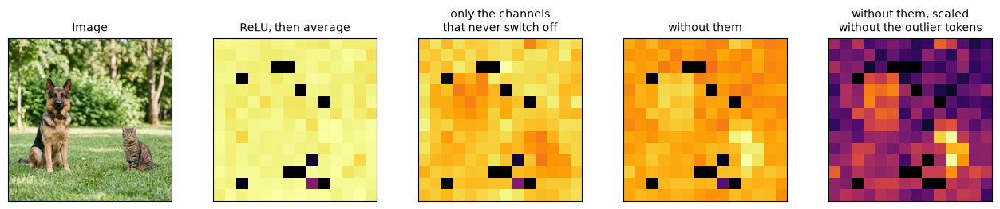

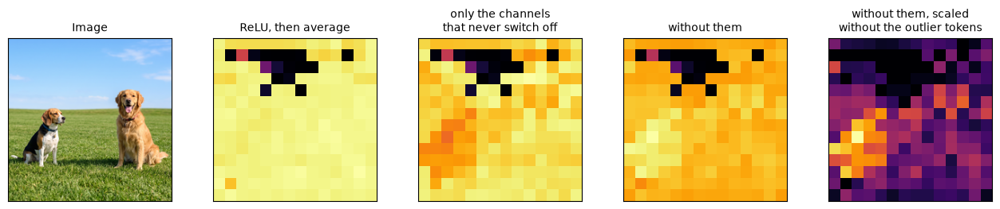

In [25]:
vit = load_model('vit')
for name in ['dog_and_cat', 'two_dogs']:
    features = vit(vit.transform(images[name])[None].to(device))[0]
    always_on = (features > 0).flatten(1).float().mean(1) >= 0.9   # positive at 9 of 10 tokens or more
    relu_map = F.relu(features).mean(0)
    without = F.relu(features[~always_on]).mean(0)

    median = relu_map.median()
    outliers = (median - relu_map) / (relu_map - median).abs().median() > 6
    rescaled = without.clone()
    rescaled[outliers] = without[~outliers].min()   # the outlier tokens no longer set the bottom of the scale

    show_images([images[name], relu_map, F.relu(features[always_on]).mean(0), without, rescaled],
                ['Image', 'ReLU, then average', 'only the channels\nthat never switch off',
                 'without them', 'without them, scaled\nwithout the outlier tokens'])

The outlier tokens are not weak inside the network. The next cell looks at the tokens just before the final layer normalization. There, the outlier tokens hold by far the largest values, always in the same channel. The layer normalization divides every token by the spread of its values. In an outlier token, that spread comes almost entirely from the one huge channel, so all other channels shrink to nearly zero, and the token comes out dark in the ReLU map. Darcet et al. describe such tokens in [Vision Transformers Need Registers](https://arxiv.org/abs/2309.16588), where the registers remove them.

largest value in an outlier token 1404, in an ordinary token 63
channel holding it in every outlier token: [187]


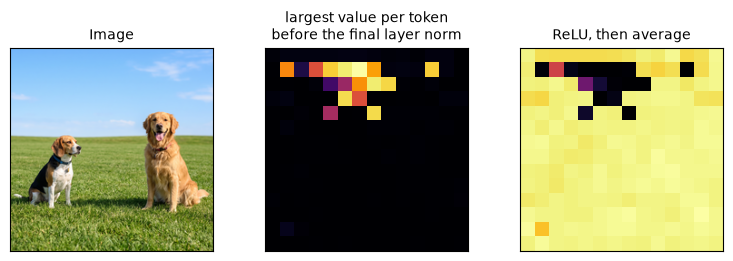

In [26]:
two_dogs = images['two_dogs']
before = {}
hook = vit.model.norm.register_forward_hook(lambda module, inputs, output: before.update(tokens=inputs[0]))
features = vit(vit.transform(two_dogs)[None].to(device))[0]
hook.remove()

tokens = before['tokens'][0, vit.model.num_prefix_tokens:].cpu()   # (196, 768) before the final layer norm
largest = tokens.abs().max(1)
relu_map = F.relu(features).mean(0).cpu()
median = relu_map.median()
outliers = ((median - relu_map) / (relu_map - median).abs().median() > 6).flatten()
print('largest value in an outlier token', f'{largest.values[outliers].max():.0f},',
      'in an ordinary token', f'{largest.values[~outliers].max():.0f}')
print('channel holding it in every outlier token:', sorted(set(largest.indices[outliers].tolist())))
show_images([two_dogs, largest.values.reshape(14, 14), relu_map],
            ['Image', 'largest value per token\nbefore the final layer norm', 'ReLU, then average'])

The remedy from the post is to center each channel before the ReLU. From every channel, we subtract its average over all tokens of the image. The channel is then positive exactly where it is higher than usual in this image, whatever its overall level. The channels are only shifted, not rescaled, and the map still uses only this one image.

The second figure compares both reductions for the three encoders that fail, adds AnyUp on the centered features, and LRP, which does not use either reduction.

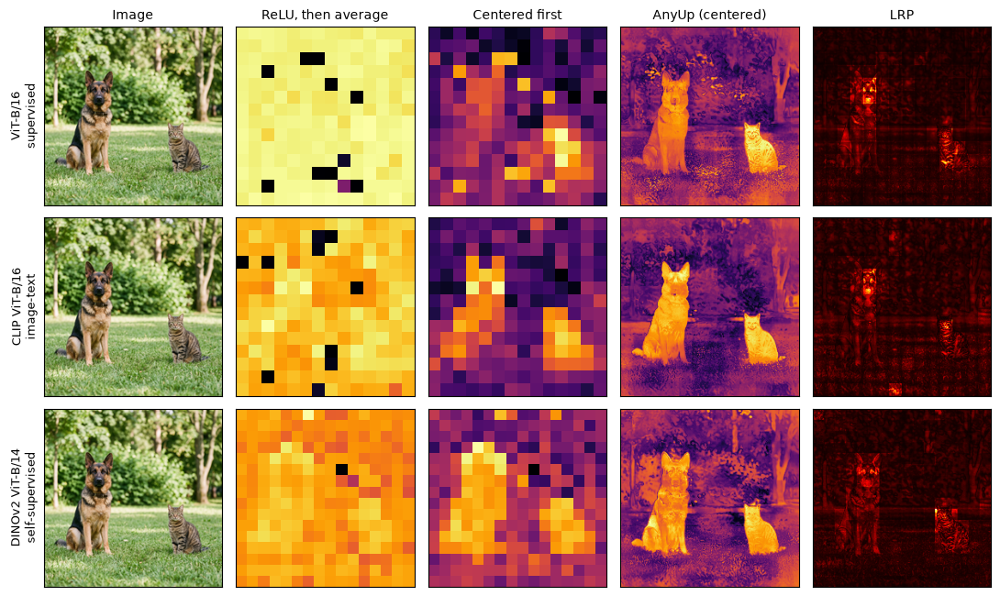

In [27]:
IMAGE = 'dog_and_cat'
SECOND_GALLERY = ['vit', 'clip_vit', 'dinov2']

image = images[IMAGE]
guide = imagenet_transform(image)[None].to(device)
rows = []
for key in SECOND_GALLERY:
    model = load_model(key)
    x = model.transform(image)[None].to(device)
    features = model(x)[0]
    centered = features - features.mean(dim=(1, 2), keepdim=True)   # each channel minus its average over the image
    upsampled = upsampler(guide, features[None])[0]
    upsampled_centered = upsampled - upsampled.mean(dim=(1, 2), keepdim=True)
    relevance = explain(model, x)
    maps = [F.relu(features).mean(0), F.relu(centered).mean(0), F.relu(upsampled_centered).mean(0),
            relevance.clamp(min=0).mean(0)]
    rows.append((f'{model.info.label}\n{model.info.training}', maps))

show_rows(image, rows, ['ReLU, then average', 'Centered first', 'AnyUp (centered)', 'LRP'],
          cmaps=['inferno', 'inferno', 'inferno', 'hot'])

### A fish the models do not need

In the photo of the fish, the supervised ViT's centered map is darker on the fish than on the person holding it. Is this a flaw of the map, or does it reflect the model? To find out, we removed the fish from the photo with an image-editing model and ask eight supervised classifiers, the five from the post and three more ViTs, for their prediction on both versions.

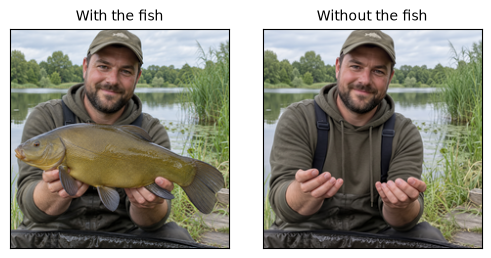

ResNet-50            with the fish: tench 0.999, top class tench   without the fish: tench 0.561, top class tench


ConvNeXt Base        with the fish: tench 0.928, top class tench   without the fish: tench 0.953, top class tench


Swin Base            with the fish: tench 0.908, top class tench   without the fish: tench 0.928, top class tench


MaxViT Base          with the fish: tench 0.819, top class tench   without the fish: tench 0.847, top class tench


ViT-B/16             with the fish: tench 1.000, top class tench   without the fish: tench 0.937, top class tench


ViT-B/16 (AugReg)    with the fish: tench 0.999, top class tench   without the fish: tench 0.955, top class tench


DeiT-B               with the fish: tench 0.860, top class tench   without the fish: tench 0.903, top class tench


DeiT III-B           with the fish: tench 0.884, top class tench   without the fish: tench 0.890, top class tench


In [28]:
TENCH = 0   # 'tench', the fish in the photo
photos = {
    'with the fish': images['fish_and_person'],
    'without the fish': crop(Image.open('images/edited/person_without_fish.jpeg').convert('RGB')),
}
show_images(list(photos.values()), [title.capitalize() for title in photos])

for key in ['resnet50', 'convnext', 'swin', 'maxvit', 'vit', 'vit_augreg', 'deit', 'deit3']:
    classifier = load_model(key)
    line = f'{classifier.info.label:18s}'
    for title, photo in photos.items():
        x = classifier.transform(photo)[None].to(device)
        probabilities = classifier.model(x)[0].softmax(-1)
        top_class = classes.index_to_description(int(probabilities.argmax())).split(',')[0]
        line += f'   {title}: tench {probabilities[TENCH]:.3f}, top class {top_class}'
    print(line)

Every classifier still predicts a tench without the fish, and most of them are even more confident. ImageNet photos of tench usually show an angler holding the catch, so the models have learned the scene rather than the fish. This is a well-known shortcut ([Geirhos et al., 2020](https://arxiv.org/abs/2004.07780)), and finding such shortcuts is what attribution methods were made for.

Grad-CAM (section 5) and RISE (section 2) show where the supervised ViT finds its tench evidence in both photos. RISE uses the tench logit here, because the probability for the photo with the fish is saturated at almost exactly 1.

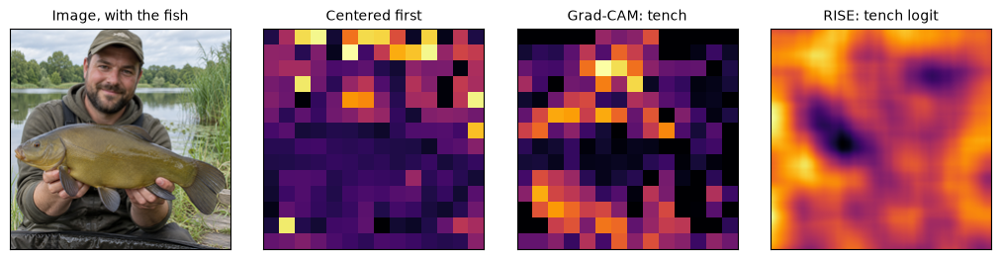

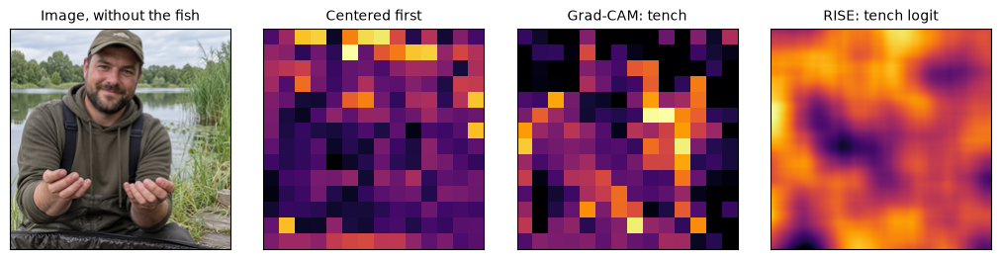

In [29]:
vit = load_model('vit')
for title, photo in photos.items():
    x = vit.transform(photo)[None].to(device)
    features = vit(x)[0]
    centered = features - features.mean(dim=(1, 2), keepdim=True)

    logits = []
    for batch in masks.split(100):   # RISE with the same masks as in section 2
        logits.append(vit.model(x * batch[:, None].to(device))[:, TENCH].cpu())
    rise = (torch.cat(logits) @ masks.flatten(1) / (N_MASKS * P)).reshape(224, 224)

    show_images([photo, F.relu(centered).mean(0), grad_cam_vit(vit.model, x, TENCH, vit.model.blocks[-1].norm1), rise],
                [f'Image, {title}', 'Centered first', 'Grad-CAM: tench', 'RISE: tench logit'])

With the fish, Grad-CAM finds the tench evidence mostly around the face and the hands, and RISE around the edges of the photo, while the middle of the fish stays dark. Without the fish, Grad-CAM moves to the empty hands, and RISE to the reeds and the water. The label-free map pointed to this before we asked the classifier anything. The fish is dark because the model barely needs it.

## What is not in this notebook

The post also summarizes the quantitative evaluation of the LaFAM paper on
ImageNet-S and PASCAL VOC. That evaluation is not reproduced here; see the
[LaFAM repository](https://github.com/karray/LaFAM).